# Access MITHO

    * Original Data Source: https://zenodo.org/records/17191460
    * Reference:  https://opensciencedata.esa.int/products/global-cumulative-hazard-indexes-chis/collection.json
    * OSC entry: https://opensciencedata.esa.int/products/global-cumulative-hazard-indexes-chis/collection.json
    * License: CC-BY-4.0

In [1]:
zarr_href1 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/ch13.zarr/'
zarr_href2 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/chi2_2004_2022.zarr/'
zarr_href3 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/chi4_2012_2020.zarr/'

zarr_href1 = '/run/media/krasen/Storage/ocean/processed/mitho/ch13.zarr/'
zarr_href2 = '/run/media/krasen/Storage/ocean/processed/mitho/chi2_2004_2022.zarr/'
zarr_href3 = '/run/media/krasen/Storage/ocean/processed/mitho/chi4_2012_2020.zarr/'


In [3]:
import xarray as xr
ds = xr.open_zarr(zarr_href1)
ds

<xarray.Dataset> Size: 6GB
Dimensions:            (time: 360, latitude: 180, longitude: 360,
                        intensity_class: 3)
Coordinates:
  * time               (time) datetime64[ns] 3kB 1993-01-01 ... 2022-12-01
  * latitude           (latitude) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * longitude          (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * intensity_class    (intensity_class) float64 24B 0.0 1.0 2.0
Data variables: (12/48)
    CH1_CHI1           (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH1_CHI1_Cat       (intensity_class, latitude, longitude) int32 778kB dask.array<chunksize=(3, 180, 360), meta=np.ndarray>
    CH1_CHI1_mav       (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH1_CHI1_mav_Cat   (intensity_class, latitude, longitude) int32 778kB dask.array<chunksize=(3, 180, 360), meta=np.ndarray>
    CH1_CHI1_mav_mean  (latitude, longitude) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
    CH1_CHI1_mav_norm  (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    ...                 ...
    CH3_S_LWind        (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH3_S_LWind_mav    (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH3_S_MHW          (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH3_S_MHW_mav      (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH3_S_PH           (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
    CH3_S_PH_mav       (time, latitude, longitude) float64 187MB dask.array<chunksize=(180, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    title:        Global CHI1 and Stressor Dataset (1993–2022)
    summary:      CHI1 indices (with their normalized versions) and related s...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...
    history:

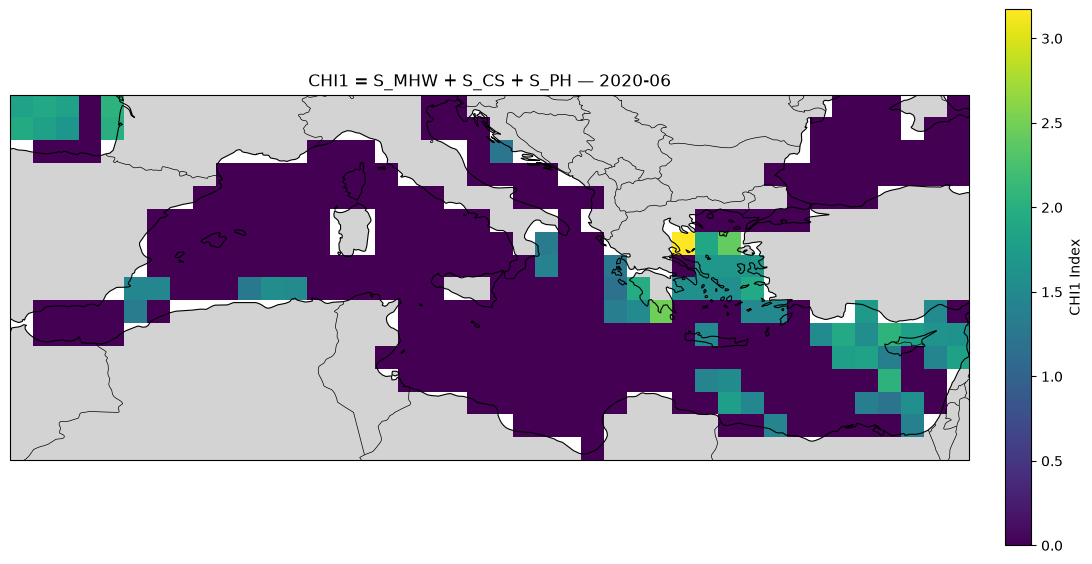

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Choose date
date = "2020-06"

# Select FSLE for that date
pp = ds["CH1_CHI1"].sel(time=np.datetime64(date), longitude=slice(-6.062, 36.06), latitude=slice(30.27, 45.98), drop=True)

# 2-D coordinates
lon = pp["longitude"]
lat = pp["latitude"]

# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot FSLE
pcm = ax.pcolormesh(
    lon,
    lat,
    pp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)


# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("CHI1 Index")

ax.set_title(f"CHI1 = S_MHW + S_CS + S_PH — {date}")

plt.tight_layout()
plt.show()